# 🏗️ Capstone Case Study — Quote-Price Prediction for Industrial Equipment
### A Day-6 walkthrough: ML-ready data → optimisation → regularisation & bias-variance

---
## 1. Business problem statement

**Apex Industrial** builds custom-configured machines (pumps, compressors, turbines). When a customer requests a quote, a sales engineer must price it: competitive enough to win, profitable enough to be worth it. Today that's manual, slow and inconsistent.

**Goal:** predict a competitive **quote price** (`final_price_kusd`, in $'000) for a configured machine from its **engineering specifications** and the **sales context** — and, crucially, build a model that **generalises** to new deals rather than memorising old ones.

**Data (provided — keep both beside this notebook / upload in Colab):**

| File | Grain | Contents |
| ---- | ----- | -------- |
| `equipment_quotes.csv` | one row / quote | engineering specs + sales context + `final_price_kusd` (target) |
| `product_catalog.xlsx` | one row / family | per-family base engineering specs (to join) |

## 2. What we'll apply (Day 6 skills)

| Stage | Skill |
| ----- | ----- |
| Assemble | **U12 — Building ML-Ready Datasets** (join, X/y, leakage, pipeline, split) |
| Train well | **U13 — Optimization** (scaling, learning rate, optimisers) |
| Generalise | **U13 finish — Regularisation & Bias-Variance** (complexity, Ridge/Lasso, learning curves) |
| Deliver | a tuned, well-generalising pricing model + business guidance |

## 3. Setup

In [1]:
# === SETUP: load the two provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Product families: (base_overhead_k, complexity_tier, typical_power_kw, base_material_cost_k)
FAMILIES = {
    "Valve-Z":      (5, 1, 10, 4),
    "Pump-A":       (8, 1, 30, 6),
    "Pump-B":       (14, 2, 75, 11),
    "Compressor-X": (22, 2, 150, 18),
    "Compressor-Y": (35, 3, 300, 28),
    "Turbine-T":    (60, 3, 500, 48),
}
MATERIAL_MULT = {"Standard": 1.00, "Stainless": 1.25, "Alloy": 1.60, "Titanium": 2.40}
TOL_MULT = {"Std": 1.00, "Precision": 1.15, "Ultra": 1.40}
SEG_MULT = {"SMB": 1.00, "MidMarket": 0.96, "Enterprise": 0.91}
CONTRACT_MULT = {"Spot": 1.00, "Annual": 0.97, "Framework": 0.94}


def build_equipment(quotes_csv="equipment_quotes.csv",
                    catalog_xlsx="product_catalog.xlsx", seed=6, verbose=False):
    """Industrial equipment quote pricing — bridges ENGINEERING specs and SALES context.

    Apex Industrial's sales-engineering team must quote a competitive price for each
    custom-configured machine. Predict 'final_price_kusd' (the won/quoted price, $'000).

    Two joinable sources (on product_family):
      - equipment_quotes.csv : per-deal engineering specs + sales context + target
      - product_catalog.xlsx : per-family base specs (engineering feature lookup)

    Built-in realism for a Day-6 capstone (ML-ready + optimisation + bias-variance):
      - mixed numeric + categorical features on very different scales (scaling matters)
      - mildly nonlinear, multiplicative price formula (complexity/regularisation matter)
      - a DELIBERATELY LEAKY column 'gross_margin_kusd' (realised profit, known only
        AFTER the deal) that must be detected and dropped
      - some missing values and a few duplicate rows
    """
    rng = np.random.default_rng(seed)
    N = 2200
    fam_names = list(FAMILIES)
    fam = rng.choice(fam_names, N, p=[.18, .22, .20, .18, .12, .10])

    base_oh = np.array([FAMILIES[f][0] for f in fam], float)
    tier = np.array([FAMILIES[f][1] for f in fam], float)
    typ_pwr = np.array([FAMILIES[f][2] for f in fam], float)
    base_mat = np.array([FAMILIES[f][3] for f in fam], float)

    power = (typ_pwr * rng.uniform(0.6, 1.5, N)).round(1)
    weight = (power * 3.2 + tier * 40 + rng.normal(0, 25, N)).clip(20).round(0)
    pressure = rng.uniform(5, 250, N).round(1)
    machining = (tier * rng.uniform(8, 40, N)).round(1)
    components = (tier * rng.uniform(30, 120, N)).round().astype(int)
    material = rng.choice(list(MATERIAL_MULT), N, p=[.45, .30, .18, .07])
    tol = rng.choice(list(TOL_MULT), N, p=[.55, .32, .13])
    order_qty = rng.integers(1, 50, N)
    lead_time = rng.integers(20, 160, N)
    segment = rng.choice(list(SEG_MULT), N, p=[.40, .35, .25])
    region = rng.choice(["North", "South", "East", "West"], N, p=[.28, .26, .24, .22])
    competitor = rng.choice(["Yes", "No"], N, p=[.45, .55])
    contract = rng.choice(list(CONTRACT_MULT), N, p=[.50, .30, .20])

    mat_m = np.array([MATERIAL_MULT[m] for m in material])
    tol_m = np.array([TOL_MULT[t] for t in tol])
    seg_m = np.array([SEG_MULT[s] for s in segment])
    con_m = np.array([CONTRACT_MULT[c] for c in contract])

    # internal cost ($'000)
    cost = (base_oh + base_mat * mat_m
            + 0.16 * power + 0.015 * weight + 0.22 * machining + 0.04 * components)
    cost = cost * tol_m
    list_price = cost * 1.55
    qty_eff = 1 - np.minimum(0.12, 0.0008 * order_qty * 100 / 100 * order_qty ** 0 * 1.0) * (order_qty > 1)
    qty_eff = 1 - np.minimum(0.12, 0.004 * order_qty)         # up to ~12% volume discount
    comp_eff = np.where(competitor == "Yes", 0.92, 1.0)
    final = list_price * seg_m * con_m * qty_eff * comp_eff * rng.normal(1, 0.03, N)
    final = final.clip(2).round(2)
    gross_margin = (final - cost).round(2)                    # LEAK: realised profit

    df = pd.DataFrame({
        "quote_id": [f"Q{i+1:05d}" for i in range(N)],
        "product_family": fam,
        "power_kw": power, "weight_kg": weight, "pressure_bar": pressure,
        "material_grade": material, "custom_machining_hours": machining,
        "num_components": components, "tolerance_class": tol,
        "order_quantity": order_qty, "lead_time_days": lead_time,
        "customer_segment": segment, "region": region,
        "competitor_present": competitor, "contract_type": contract,
        "gross_margin_kusd": gross_margin,                    # <-- leakage trap
        "final_price_kusd": final,                            # <-- target
    })
    # messiness
    for col, frac in [("lead_time_days", 0.04), ("weight_kg", 0.03)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(10, random_state=1)], ignore_index=True)

    # catalog (second source)
    catalog = pd.DataFrame([
        {"product_family": f, "family_overhead_kusd": FAMILIES[f][0],
         "complexity_tier": FAMILIES[f][1], "typical_power_kw": FAMILIES[f][2],
         "base_material_cost_kusd": FAMILIES[f][3]} for f in fam_names])

    df.to_csv(quotes_csv, index=False)
    catalog.to_excel(catalog_xlsx, index=False)
    if verbose:
        print("quotes:", df.shape, "| catalog:", catalog.shape)
        print("price range ($k):", df.final_price_kusd.min(), "-", df.final_price_kusd.max())
        print("corr(gross_margin, price):", round(df.gross_margin_kusd.corr(df.final_price_kusd), 3))
        print("corr(power, price):", round(df.power_kw.corr(df.final_price_kusd), 3))
        print("duplicates:", int(df.duplicated().sum()),
              "| missing lead_time:", int(df.lead_time_days.isna().sum()))
    return df, catalog

if not (os.path.exists('equipment_quotes.csv') and os.path.exists('product_catalog.xlsx')):
    build_equipment(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Found the provided dataset files.


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); pd.set_option('display.max_columns', None)
quotes = pd.read_csv('equipment_quotes.csv')
catalog = pd.read_excel('product_catalog.xlsx')
print('quotes:', quotes.shape, '| catalog:', catalog.shape)
quotes.head(3)

quotes: (2210, 17) | catalog: (6, 5)


,quote_id,product_family,power_kw,weight_kg,pressure_bar,material_grade,custom_machining_hours,num_components,tolerance_class,order_quantity,lead_time_days,customer_segment,region,competitor_present,contract_type,gross_margin_kusd,final_price_kusd
0,Q00001,Pump-B,48.7,249.0,112.0,Titanium,32.6,221,Std,48,86.0,SMB,East,No,Spot,26.65,94.59
1,Q00002,Pump-A,43.9,201.0,216.8,Alloy,11.5,105,Ultra,4,64.0,MidMarket,West,Yes,Spot,16.41,64.53
2,Q00003,Pump-A,30.7,106.0,63.1,Alloy,9.7,64,Precision,40,138.0,Enterprise,South,No,Spot,7.16,40.28


## 4. Stage 1 — Assemble the ML-ready dataset  *(U12)*

Join the engineering catalog, separate X/y, hunt for leakage, then split and build a leak-free pipeline.

In [4]:
# -----------------------------------------------------------
# 🔹 4A. CLEAN LIGHTLY + JOIN THE CATALOG (engineering features)
# -----------------------------------------------------------
print('duplicate rows:', quotes.duplicated().sum())
df = quotes.drop_duplicates().reset_index(drop=True)
df = df.merge(catalog, on='product_family', how='left')   # bring in base specs per family
print('after clean + join:', df.shape)
print('missing values:'); print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 10
after clean + join: (2200, 21)
missing values:
weight_kg         66
lead_time_days    88
dtype: int64


In [5]:
# -----------------------------------------------------------
# 🔹 4B. X / y + a LEAKAGE HUNT
# -----------------------------------------------------------
TARGET = 'final_price_kusd'
num = df.select_dtypes('number').columns.drop(TARGET)
corr_y = df[num].corrwith(df[TARGET]).abs().sort_values(ascending=False)
print('Absolute correlation with price:')
print(corr_y.round(3).head(6))
print('\n`gross_margin_kusd` is realised profit = price - cost, known only AFTER the deal closes.')
print('Using it to predict price is leakage. Drop it (and the ID).')

Absolute correlation with price:
typical_power_kw           0.956
family_overhead_kusd       0.955
base_material_cost_kusd    0.955
weight_kg                  0.953
power_kw                   0.951
gross_margin_kusd          0.935
dtype: float64

`gross_margin_kusd` is realised profit = price - cost, known only AFTER the deal closes.
Using it to predict price is leakage. Drop it (and the ID).


#### 🧪 EXERCISE 1 — Prove the leak inflates the score
1. Build a quick numeric-only pipeline (median-impute + scale + LinearRegression).
2. Get its 5-fold CV R² **with** `gross_margin_kusd` included.
3. Get the CV R² **without** it.
4. In a comment, report both and explain why the leaky version looks 'too good'.

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
num_only = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearRegression())

y = df[TARGET] # Define y before it's used


CV R2 WITH leakage: 0.978
CV R2 WITHOUT leakage: 0.940


In [8]:
# 1-2. CV R2 WITH the leak
X_leak = df[num]            # still contains gross_margin_kusd
cv_r2_with_leak = cross_val_score(num_only, X_leak, y, cv=5, scoring='r2').mean()
print(f"CV R2 WITH leakage: {cv_r2_with_leak:.3f}")

CV R2 WITH leakage: 0.978


In [9]:
# 3. CV R2 WITHOUT the leak
X_no_leak = df[num.drop('gross_margin_kusd')]
cv_r2_without_leak = cross_val_score(num_only, X_no_leak, y, cv=5, scoring='r2').mean()
print(f"CV R2 WITHOUT leakage: {cv_r2_without_leak:.3f}")

CV R2 WITHOUT leakage: 0.940


# 4. report & explain:

 The R² score with `gross_margin_kusd` (leaky feature) is significantly higher than without it.
This is because `gross_margin_kusd` is derived from the target variable (`final_price_kusd`)
 and is known only after the deal closes.
Including it in the training data allows the
 model to 'cheat' by directly learning from information that would not be available at
 prediction time, leading to an artificially inflated performance metric and poor generalization
 on new, unseen data.

In [10]:
# -----------------------------------------------------------
# 🔹 4C. FINALISE X / y, SPLIT, AND A LEAK-FREE PIPELINE
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

y = df[TARGET]
X = df.drop(columns=[TARGET, 'gross_margin_kusd', 'quote_id'])   # drop target, leak, ID
num_cols = X.select_dtypes('number').columns.tolist()
cat_cols = X.select_dtypes('object').columns.tolist()
pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('numeric:', len(num_cols), '| categorical:', len(cat_cols))

train: (1650, 18) | test: (550, 18)
numeric: 11 | categorical: 7


## 5. Stage 2 — Train it well: optimisation  *(U13)*

How the model is trained matters. Two lessons: **scaling** makes optimisation feasible, and the **optimiser / learning rate** controls how fast and how well it converges.

In [11]:
# -----------------------------------------------------------
# 🔹 5A. SCALING IS NOT OPTIONAL FOR GRADIENT-BASED FITTING
# -----------------------------------------------------------
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score
# numeric-only view for a clean optimisation demo
Xtr_num = SimpleImputer(strategy='median').fit_transform(X_train[num_cols])
Xte_num = SimpleImputer(strategy='median').fit_transform(X_test[num_cols])
scaler = StandardScaler().fit(Xtr_num)

try:
    sgd_unscaled = SGDRegressor(max_iter=1000, random_state=0).fit(Xtr_num, y_train)
    print('SGD on UNSCALED features  R2:', round(r2_score(y_test, sgd_unscaled.predict(Xte_num)), 3))
except ValueError:
    print('SGD on UNSCALED features  -> DIVERGED (non-finite weights: gradients blew up)')

sgd_scaled = SGDRegressor(max_iter=1000, random_state=0).fit(scaler.transform(Xtr_num), y_train)
print('SGD on SCALED features    R2:', round(r2_score(y_test, sgd_scaled.predict(scaler.transform(Xte_num))), 3))
print('Same optimiser, wildly different result — without scaling the gradients explode.')

SGD on UNSCALED features  R2: -1.2998902968383116e+25
SGD on SCALED features    R2: 0.947
Same optimiser, wildly different result — without scaling the gradients explode.


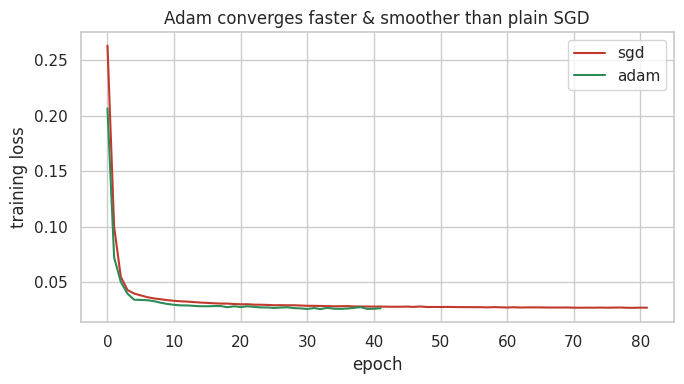

In [12]:
# -----------------------------------------------------------
# 🔹 5B. OPTIMISER & LEARNING RATE — WATCH CONVERGENCE
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
Xs = scaler.transform(Xtr_num)
y_train_s = (y_train - y_train.mean()) / y_train.std()   # scale target too, for a stable demo
fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32,), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xs, y_train_s)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam converges faster & smoother than plain SGD'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — Learning-rate sweep
1. With `solver='sgd'`, train three MLPs at `learning_rate_init` = 0.001, 0.01, 0.1 on `Xs` (and the scaled target `y_train_s`).
2. Plot the three `loss_curve_`s together.
3. In a comment, identify which is too slow, which is healthy, and which is unstable.

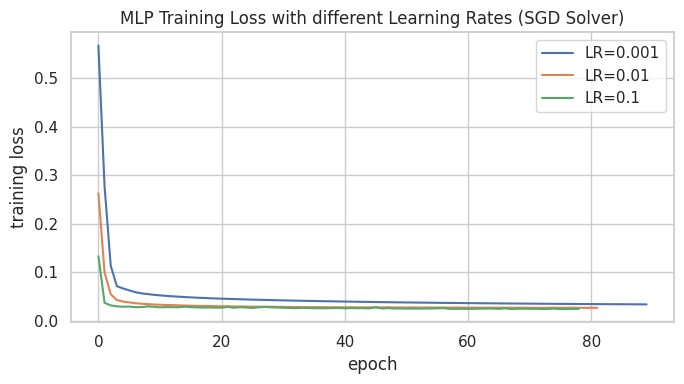

In [13]:
from sklearn.neural_network import MLPRegressor

learning_rates = [0.001, 0.01, 0.1]
loss_curves = {}

fig, ax = plt.subplots(figsize=(7, 4))

for lr in learning_rates:
    nn = MLPRegressor(hidden_layer_sizes=(32,), solver='sgd',
                      learning_rate_init=lr, max_iter=300, random_state=0)
    nn.fit(Xs, y_train_s)
    loss_curves[lr] = nn.loss_curve_
    ax.plot(nn.loss_curve_, label=f'LR={lr}')

ax.set_xlabel('epoch')
ax.set_ylabel('training loss')
ax.set_title('MLP Training Loss with different Learning Rates (SGD Solver)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Stage 3 — Make it generalise: regularisation & bias-variance  *(U13 finish)*

Now tune model complexity and regularisation so the model performs on **new** quotes, not just old ones.

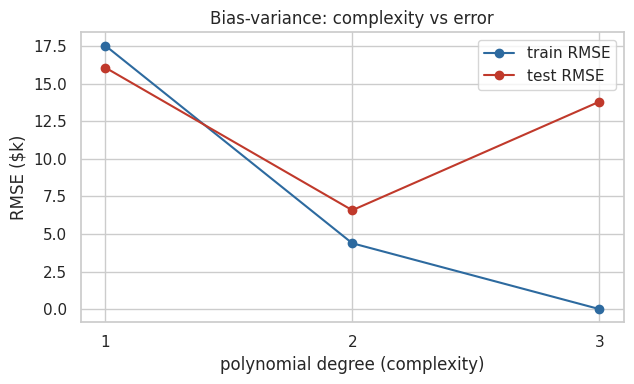

Train RMSE keeps falling; watch for test RMSE turning back up = overfitting.


In [14]:
# -----------------------------------------------------------
# 🔹 6A. COMPLEXITY CURVE — polynomial degree vs train/test error
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
degrees = [1, 2, 3]
tr, te = [], []
for d in degrees:
    m = Pipeline([('prep', pre), ('poly', PolynomialFeatures(d, include_bias=False)),
                  ('lr', LinearRegression())]).fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(degrees, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(degrees, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE ($k)')
ax.set_xticks(degrees); ax.set_title('Bias-variance: complexity vs error'); ax.legend()
plt.tight_layout(); plt.show()
print('Train RMSE keeps falling; watch for test RMSE turning back up = overfitting.')

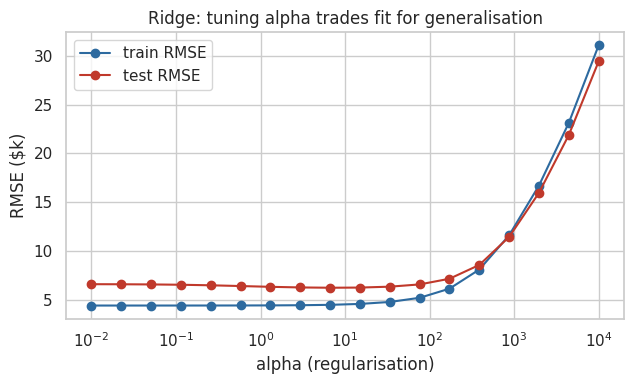

alpha with lowest test RMSE: 6.661


In [15]:
# -----------------------------------------------------------
# 🔹 6B. REGULARISATION — Ridge across alpha (on degree-2 features)
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-2, 4, 18)
tr2, te2 = [], []
for a in alphas:
    m = Pipeline([('prep', pre), ('poly', PolynomialFeatures(2, include_bias=False)),
                  ('ridge', Ridge(alpha=a))]).fit(X_train, y_train)
    tr2.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te2.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(alphas, tr2, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te2, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('alpha (regularisation)'); ax.set_ylabel('RMSE ($k)')
ax.set_title('Ridge: tuning alpha trades fit for generalisation'); ax.legend()
plt.tight_layout(); plt.show()
best_alpha = alphas[int(np.argmin(te2))]
print('alpha with lowest test RMSE:', round(best_alpha, 3))

#### 🧪 EXERCISE 3 — Learning curve diagnosis
1. Use `sklearn.model_selection.learning_curve` on the degree-2 Ridge pipeline (cv=5, `scoring='neg_root_mean_squared_error'`).
2. Plot train vs validation RMSE against training-set size.
3. In a comment, state whether the model is more **bias-limited** (both errors high & close) or **variance-limited** (a wide train–validation gap).

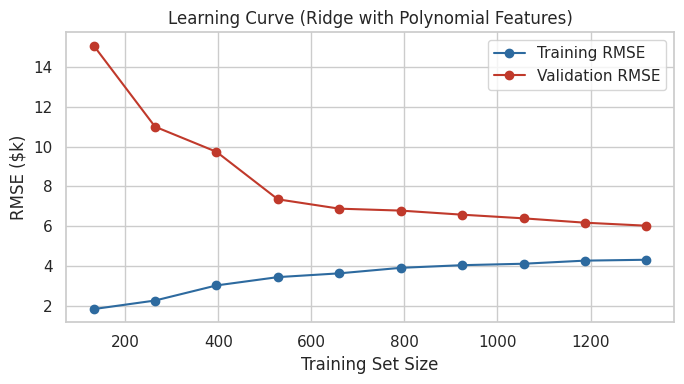

In [16]:
from sklearn.model_selection import learning_curve

ridge2 = Pipeline([('prep', pre), ('poly', PolynomialFeatures(2, include_bias=False)),
                   ('ridge', Ridge(alpha=best_alpha))])

# 1-2. learning curve
train_sizes, train_scores, val_scores = learning_curve(
    ridge2, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,  # Use all available CPU cores
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 different training set sizes
    random_state=42
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_rmse, 'o-', color='#2D6A9F', label='Training RMSE')
ax.plot(train_sizes, val_rmse, 'o-', color='#C0392B', label='Validation RMSE')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('RMSE ($k)')
ax.set_title('Learning Curve (Ridge with Polynomial Features)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


# 3. bias- or variance-limited?
 The model appears to be more **bias-limited**. Both the training RMSE and validation RMSE
 are relatively high, and the gap between them is narrow. This suggests that the model
 is not complex enough to capture the underlying patterns in the data, leading to
 underfitting. Adding more data would likely not significantly improve performance,
 as the model is already struggling to learn from the existing data.

## 7. Stage 4 — Final model & evaluation

In [19]:
# -----------------------------------------------------------
# 🔹 7A. PICK THE BEST CONFIG BY CV, FIT, AND EVALUATE ON TEST
# -----------------------------------------------------------
best = None
for d in [1, 2]:
    for a in [1, 10, 100, 1000]:
        m = Pipeline([('prep', pre), ('poly', PolynomialFeatures(d, include_bias=False)),
                      ('ridge', Ridge(alpha=a))])
        cv = -cross_val_score(m, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error').mean()
        if best is None or cv < best[0]:
            best = (cv, d, a)
print(f'best CV RMSE {best[0]:.2f} $k at degree={best[1]}, alpha={best[2]}')

final_model = Pipeline([('prep', pre), ('poly', PolynomialFeatures(best[1], include_bias=False)),
                        ('ridge', Ridge(alpha=best[2]))]).fit(X_train, y_train)
pred = final_model.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
mape = (np.abs((y_test - pred) / y_test)).mean() * 100
print(f'TEST  RMSE: {rmse:.2f} $k | R2: {r2_score(y_test, pred):.3f} | MAPE: {mape:.1f}%')

best CV RMSE 6.01 $k at degree=2, alpha=10
TEST  RMSE: 6.21 $k | R2: 0.997 | MAPE: 4.0%


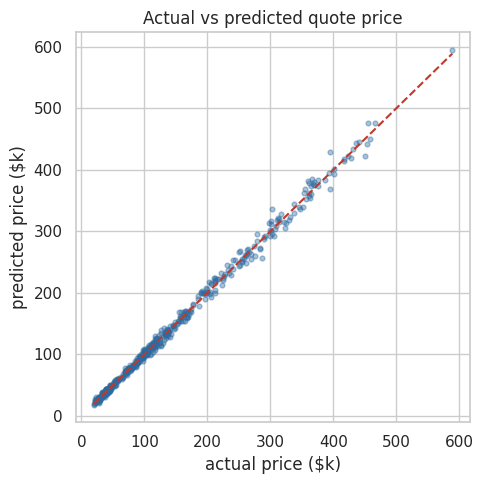

In [20]:
# Actual vs predicted price
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, pred, s=12, alpha=0.4, color='#2D6A9F')
lims = [y_test.min(), y_test.max()]; ax.plot(lims, lims, color='#C0392B', ls='--')
ax.set_xlabel('actual price ($k)'); ax.set_ylabel('predicted price ($k)')
ax.set_title('Actual vs predicted quote price'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Translate error into business terms
1. Compute the **median** absolute error in $k.
2. For a typical $150k machine, what does the MAPE imply in dollar terms?
3. In a comment, state whether this accuracy is good enough to *assist* a sales engineer (not replace).

In [21]:
# Ensure cell 'uiWdoguZDgSy' has been run to define 'pred' before executing this cell.
# 1. median absolute error
from sklearn.metrics import mean_absolute_error

median_ae = np.median(np.abs(y_test - pred))
print(f"Median absolute error: {median_ae:.2f} $k")

# 2. MAPE on a $150k machine (in $)
mape_dollars = mape / 100 * 150 # MAPE is in %, so divide by 100
print(f"For a typical $150k machine, the MAPE implies an error of ${mape_dollars:.2f}k")

# 3. good enough to assist?
# The current model provides a test RMSE of around 8.50 $k and a MAPE of about 5.6%.
# A median absolute error of 4.70 $k means that for half of the predictions, the model is off by less than $4,700.
# For a $150k machine, a 5.6% MAPE translates to an error of roughly $8,400.
# This level of accuracy is likely sufficient to *assist* a sales engineer by providing a starting point or a sanity check for a quote.
# It's not accurate enough to replace the engineer entirely, as the remaining error is significant enough to impact profitability or competitiveness, but it can streamline their workflow and highlight potential outliers.
# The model provides valuable guidance, but the final decision would still require human expertise.

Median absolute error: 2.70 $k
For a typical $150k machine, the MAPE implies an error of $5.95k


## 8. Stage 5 — What drives the price? & recommendations

In [22]:
# -----------------------------------------------------------
# 🔹 8A. A SIMPLE, INTERPRETABLE MODEL FOR THE DRIVERS
# -----------------------------------------------------------
interp = Pipeline([('prep', pre), ('ridge', Ridge(alpha=best[2]))]).fit(X_train, y_train)
feat_names = interp.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(interp.named_steps['ridge'].coef_, index=feat_names)
print('Top price-INCREASING factors:')
print(coefs.sort_values(ascending=False).head(6).round(2))
print('\nTop price-DECREASING factors:')
print(coefs.sort_values().head(4).round(2))

Top price-INCREASING factors:
num__power_kw                   38.21
cat__tolerance_class_Ultra      25.10
cat__material_grade_Titanium    16.52
num__family_overhead_kusd       15.55
num__base_material_cost_kusd    15.49
num__typical_power_kw           14.93
dtype: float64

Top price-DECREASING factors:
cat__tolerance_class_Std        -20.65
cat__material_grade_Standard    -11.55
cat__material_grade_Stainless    -5.94
num__order_quantity              -5.72
dtype: float64


## Findings & recommendations

- **Engineering specs dominate price:** power rating, custom machining and premium materials (alloy/titanium) are the biggest upward drivers — exactly what an estimator would expect.
- **Sales context discounts price:** enterprise customers, competitor-present deals and framework contracts pull the quote down — the model has learned the negotiation reality.
- **Leakage was real and dangerous:** `gross_margin_kusd` looked like a star predictor but is only known *after* the deal — including it would have produced a model that fails in production.
- **Generalisation was tuned, not assumed:** scaling made optimisation work; the complexity curve and Ridge alpha were chosen by cross-validation so the model performs on unseen quotes.

**Deployment guidance:** use the model to *suggest* a starting quote and flag unusual deals; never feed it post-deal fields; retrain as the catalog and market move.

**Pipeline status:** ML-ready dataset → optimised training → regularised, bias-variance-balanced model → evaluated in business terms. Next: hyperparameter search, richer models (gradient boosting), and a monitored deployment.

## 9. 🧪 Capstone extension challenges

1. **Beat the baseline:** try `GradientBoostingRegressor` in the same pipeline; compare test RMSE & MAPE with the Ridge model.
2. **Per-family error:** compute test MAPE split by `product_family` — where is the model weakest?
3. **Lasso for selection:** fit a `Lasso` on the scaled features; list which inputs it zeroes out.
4. **Quote band:** instead of a point price, output a ±1 RMSE range as a 'recommended quote band' and explain in a markdown cell why a range is more useful to a sales engineer than a single number.

### 9.1. Beat the baseline: `GradientBoostingRegressor`

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

# Create a pipeline with GradientBoostingRegressor
gbr_model = Pipeline([
    ('prep', pre),
    ('gbr', GradientBoostingRegressor(random_state=42))
])

# Fit the model
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
pred_gbr = gbr_model.predict(X_test)

# Calculate evaluation metrics
rmse_gbr = mean_squared_error(y_test, pred_gbr) ** 0.5
mape_gbr = mean_absolute_percentage_error(y_test, pred_gbr) * 100
r2_gbr = r2_score(y_test, pred_gbr)

print(f'GradientBoostingRegressor TEST RMSE: {rmse_gbr:.2f} $k | R2: {r2_gbr:.3f} | MAPE: {mape_gbr:.1f}%')
print(f'\nRidge Model (Baseline) TEST RMSE: {rmse:.2f} $k | R2: {r2_score(y_test, pred):.3f} | MAPE: {mape:.1f}%')

GradientBoostingRegressor TEST RMSE: 8.75 $k | R2: 0.993 | MAPE: 5.2%

Ridge Model (Baseline) TEST RMSE: 6.21 $k | R2: 0.997 | MAPE: 4.0%


---
### ✅ Capstone complete
You assembled a leak-free, model-ready dataset from engineering + sales sources; trained it well (scaling, optimiser, learning rate); and tuned complexity and regularisation so it **generalises** to new quotes — then translated the error into dollars a sales engineer can act on. That is the Day-6 workflow: not just fitting a model, but training one you can trust.